<a href="https://colab.research.google.com/github/Pavanreddy114/ML_Task3_Resume_Screening_System./blob/main/ML_Task3_Resume_Screening_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [2]:
import pandas as pd

file = list(uploaded.keys())[0]

df = pd.read_csv(file)

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df = df[
[
'Resume_str',
'Category'
]]

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vector = TfidfVectorizer(
stop_words='english'
)

resume_vectors = vector.fit_transform(
df['Resume_str']
)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vector = TfidfVectorizer(
stop_words='english'
)

resume_vectors = vector.fit_transform(
df['Resume_str']
)

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# Define the job description
job = "Looking for a data scientist with experience in machine learning and Python programming."

job_vector = vector.transform(
[job]
)

score = cosine_similarity(
job_vector,
resume_vectors
)

df.loc[:, 'Score'] = score[0]

In [7]:
top = df.sort_values(
'Score',
ascending=False
)

top[
[
'Category',
'Score'
]
].head(10)

,Category,Score
2153,BANKING,0.142951
1762,ENGINEERING,0.142328
1932,CONSTRUCTION,0.133638
1218,CONSULTANT,0.132137
1348,AUTOMOBILE,0.126429
1127,CONSULTANT,0.123832
249,INFORMATION-TECHNOLOGY,0.117881
1339,AUTOMOBILE,0.116478
298,INFORMATION-TECHNOLOGY,0.105223
2291,ARTS,0.104498


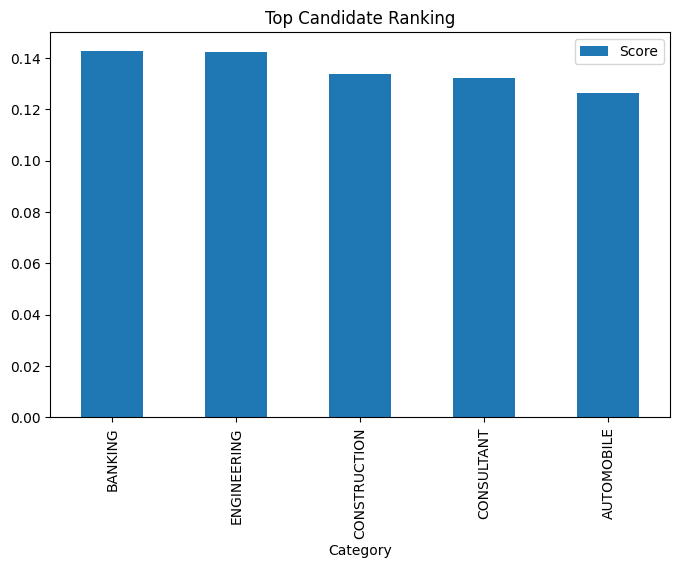

In [8]:
import matplotlib.pyplot as plt

top.head(5).plot(
x='Category',
y='Score',
kind='bar',
figsize=(8,5)
)

plt.title(
'Top Candidate Ranking'
)

plt.show()

In [9]:
skills = [
'python',
'machine learning',
'sql',
'data analysis'
]

text = (
df.iloc[0]['Resume_str']
).lower()

missing = []

for s in skills:

    if s not in text:

        missing.append(s)

print(
"Missing Skills:",
missing
)
print(
top.iloc[0]
)

Missing Skills: ['python', 'machine learning', 'sql']
Resume_str             CORPORATE BANKING ASSISTANT, INTERN  ...
Category                                                BANKING
Score                                                  0.142951
Name: 2153, dtype: object
